=== РЕАЛЬНІ СПОСТЕРЕЖЕННЯ (CITY_DATA) ===
    місяць  температура  споживання_МВтгод
0        1         -5.2             1220.0
1        2         -2.9             1210.0
2        3          1.6             1063.0
3        4          7.6              914.0
4        5         13.3              770.0
5        6         19.7              603.0
6        7         21.6              579.0
7        8         18.5              662.0
8        9         15.3              728.0
9       10          7.8              959.0
10      11          2.8              989.0
11      12         -3.0             1161.0

=== ЗАВДАННЯ 2: ОЦІНЕНІ ПАРАМЕТРИ МОДЕЛІ ===
Рівняння регресії: споживання ≈ 1102.2 + (-24.4) · температура

=== ЗАВДАННЯ 3: ТАБЛИЦЯ СПОСТЕРЕЖЕНЬ ТА ПЕРЕДБАЧЕНЬ ===
    місяць  температура  споживання_МВтгод  передбачення  залишок
0        1         -5.2             1220.0        1229.1     -9.1
1        2         -2.9             1210.0        1173.0     37.0
2        3          1.6            

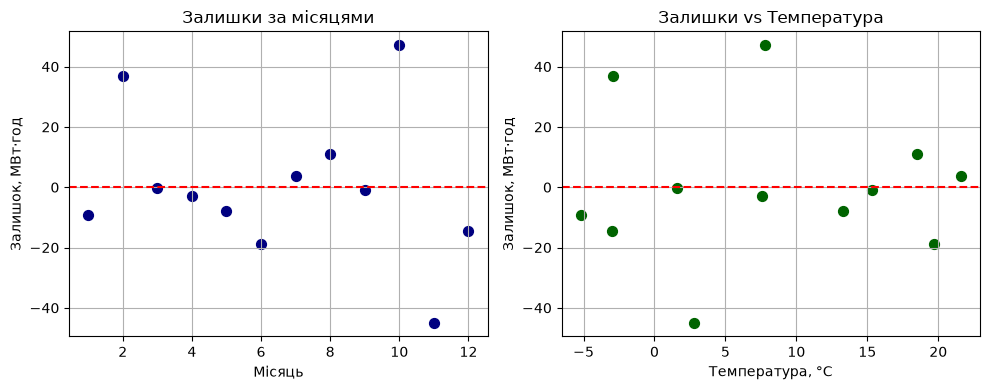


=== ЗАВДАННЯ 4: ПЕРЕВІРКА ВЕРИФІКАЦІЇ ===
Місяць 1 (температура = -5.2 °C):
  Ручний розрахунок (a + b * T): 1229.06
  Значення з коду:              1229.10
  Різниця (абсолютна похибка):   0.0372


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# ПРАКТИКА 19. ВАРІАНТ 6 (ЧЕРНІГІВ)
# ==============================================================================

np.random.seed(6)
city = "Чернігів"
base_temp = 8.0          # Средньорічна температура, °C
amplitude = 13.0         # Сезонна амплітуда, °C
base_consumption = 900   # Базове споживання, МВт·год
k = 25                   # Нахил: МВт·год/°C
noise_sd = 30            # Рівень шуму споживання, МВт·год

months = np.arange(1, 13)
temp = base_temp + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
temp = np.round(temp + np.random.normal(0, 0.5, size=12), 1)

consumption = base_consumption - k * (temp - base_temp) + np.random.normal(0, noise_sd, size=12)
consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption,
})

print("=== РЕАЛЬНІ СПОСТЕРЕЖЕННЯ (CITY_DATA) ===")
print(city_data)

# ==============================================================================
# ЗАВДАННЯ 2. ПОБУДОВА МНК-МОДЕЛІ
# ==============================================================================
b, a = np.polyfit(city_data["температура"], city_data["споживання_МВтгод"], 1)

city_data["передбачення"] = np.round(a + b * city_data["температура"], 1)

print("\n=== ЗАВДАННЯ 2: ОЦІНЕНІ ПАРАМЕТРИ МОДЕЛІ ===")
print(f"Рівняння регресії: споживання ≈ {a:.1f} + ({b:.1f}) · температура")

# ==============================================================================
# ЗАВДАННЯ 3. ОБЧИСЛЕННЯ ЗАЛИШКІВ, R² ТА ПРАФІЧНИЙ АНАЛІЗ
# ==============================================================================
city_data["залишок"] = np.round(city_data["споживання_МВтгод"] - city_data["передбачення"], 1)

print("\n=== ЗАВДАННЯ 3: ТАБЛИЦЯ СПОСТЕРЕЖЕНЬ ТА ПЕРЕДБАЧЕНЬ ===")
print(city_data[["місяць", "температура", "споживання_МВтгод", "передбачення", "залишок"]])

# Обчислення R²
ss_res = (city_data["залишок"] ** 2).sum()
ss_tot = ((city_data["споживання_МВтгод"] - city_data["споживання_МВтгод"].mean()) ** 2).sum()
r_squared = 1 - ss_res / ss_tot

print(f"\nКоефіцієнт детермінації R² = {r_squared:.4f}")

# Побудова графіка залишків
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(city_data["місяць"], city_data["залишок"], color="navy", s=50)
plt.axhline(0, color="red", linestyle="--")
plt.title("Залишки за місяцями")
plt.xlabel("Місяць")
plt.ylabel("Залишок, МВт·год")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(city_data["температура"], city_data["залишок"], color="darkgreen", s=50)
plt.axhline(0, color="red", linestyle="--")
plt.title("Залишки vs Температура")
plt.xlabel("Температура, °C")
plt.ylabel("Залишок, МВт·год")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================================================================
# ЗАВДАННЯ 4. КРОК ВЕРИФІКАЦІЇ (РУЧНИЙ РОЗРАХУНОК)
# ==============================================================================
sample_month = city_data.iloc[0]  # Січень (місяць 1)
t_val = sample_month["температура"]
pred_manual = a + b * t_val
pred_code = sample_month["передбачення"]

print("\n=== ЗАВДАННЯ 4: ПЕРЕВІРКА ВЕРИФІКАЦІЇ ===")
print(f"Місяць 1 (температура = {t_val} °C):")
print(f"  Ручний розрахунок (a + b * T): {pred_manual:.2f}")
print(f"  Значення з коду:              {pred_code:.2f}")
print(f"  Різниця (абсолютна похибка):   {abs(pred_manual - pred_code):.4f}")